In [13]:
import numpy as np 
import matplotlib.pyplot as plt

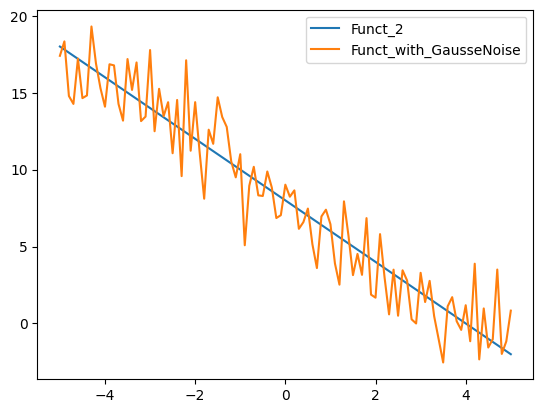

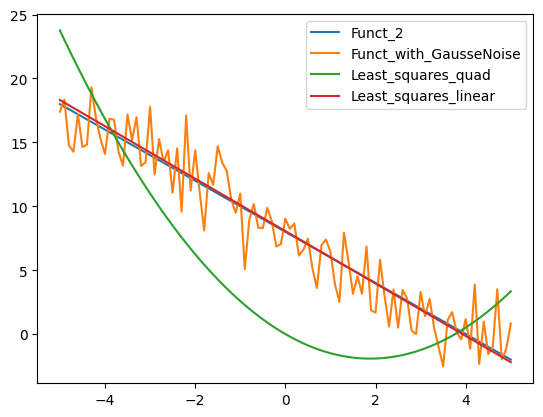

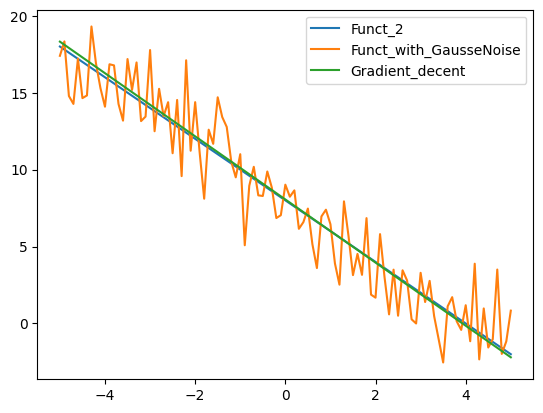

In [20]:
x_values_f2, y_values_f2 = [], []
x_values_noise, y_values_noise = [], []

with open('/home/angst/DataAnalysis/lab3/files/Funct_with_GausseNoise.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_values_noise.append(x)
        y_values_noise.append(y)


with open('/home/angst/DataAnalysis/lab3/files/Funct_2.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_values_f2.append(x)
        y_values_f2.append(y)

plt.plot(x_values_f2, y_values_f2, label='Funct_2')
plt.plot(x_values_noise, y_values_noise, label='Funct_with_GausseNoise')
plt.legend()
plt.show()

x_least_quad, y_least_quad = [], []
x_lest_linear, y_lest_linear = [], []
x_least_decent, y_least_decent = [], []

with open('/home/angst/DataAnalysis/lab3/files/Least_squares_quadratics.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_least_quad.append(x)
        y_least_quad.append(y)

with open('/home/angst/DataAnalysis/lab3/files/Least_squares_linear.txt', 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        x_lest_linear.append(x)
        y_lest_linear.append(y)

with open('/home/angst/DataAnalysis/lab3/files/Gradient_decent.txt', 'r') as file:
    for line in file:
        try:
            x, y = map(float, line.split())
            x_least_decent.append(x)
            y_least_decent.append(y)
        except ValueError:
            continue

plt.plot(x_values_f2, y_values_f2, label='Funct_2')
plt.plot(x_values_noise, y_values_noise, label='Funct_with_GausseNoise')
plt.plot(x_least_quad, y_least_quad, label='Least_squares_quad')
plt.plot(x_lest_linear, y_lest_linear, label='Least_squares_linear')
#plt.plot(x_least_decent, y_least_decent, label='Gradient_decent')
plt.legend()
plt.show()

plt.plot(x_values_f2, y_values_f2, label='Funct_2')
plt.plot(x_values_noise, y_values_noise, label='Funct_with_GausseNoise')
#plt.plot(x_least_quad, y_least_quad, label='Least_squares_quad')
#plt.plot(x_lest_linear, y_lest_linear, label='Least_squares_linear')
plt.plot(x_least_decent, y_least_decent, label='Gradient_decent')
plt.legend()
plt.show()



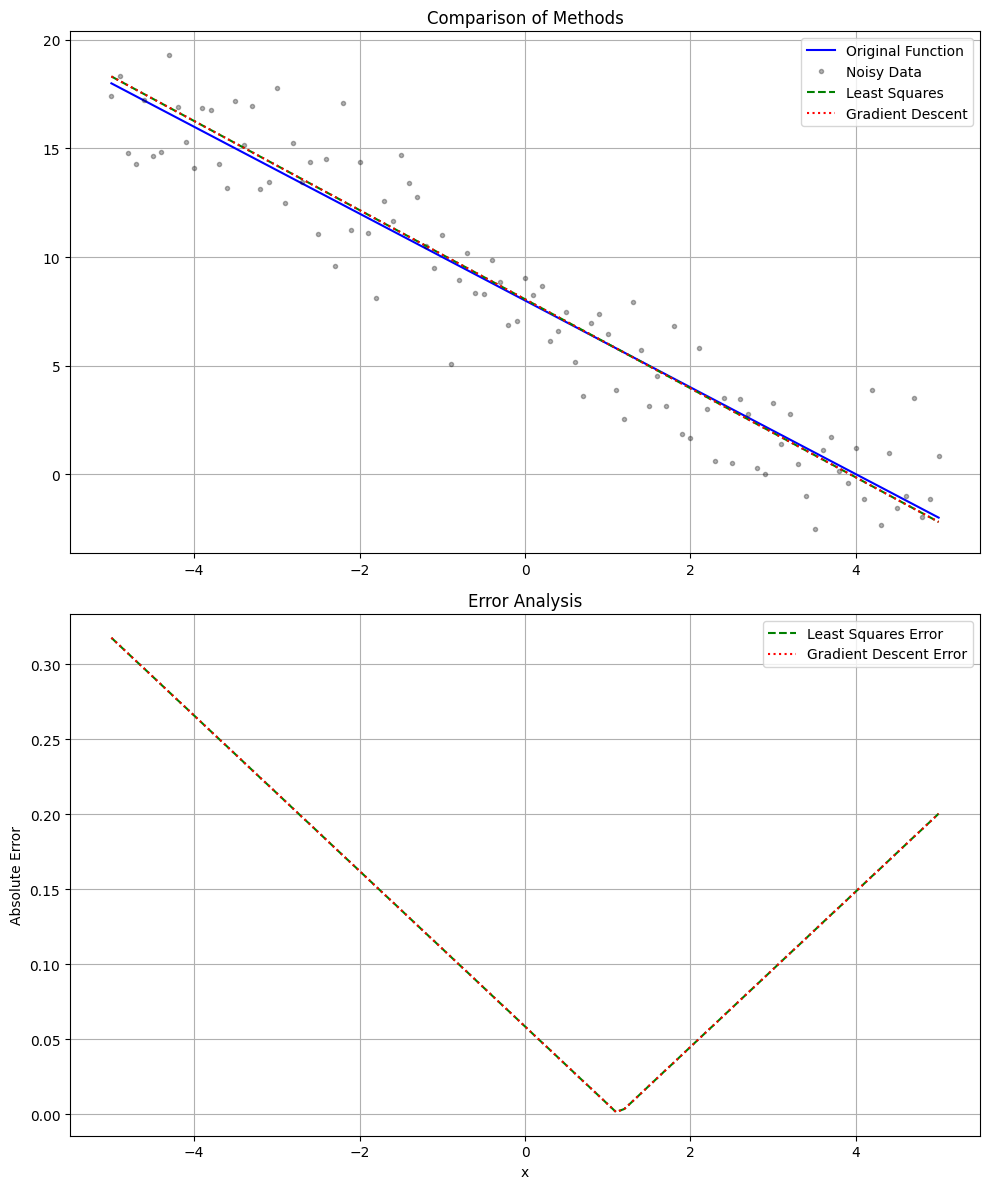


Error:
----------------------------------------
Least Squares:     Mean Error = 0.137349
Gradient Descent:  Mean Error = 0.137349


In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

ax1.plot(x_values_f2, y_values_f2, 'b-', label='Original Function')
ax1.plot(x_values_noise, y_values_noise, 'k.', alpha=0.3, label='Noisy Data')
ax1.plot(x_lest_linear, y_lest_linear, 'g--', label='Least Squares')
ax1.plot(x_least_decent, y_least_decent, 'r:', label='Gradient Descent')
ax1.set_title('Comparison of Methods')
ax1.grid(True)
ax1.legend()

x_common = np.array(x_values_f2)
y_orig = np.array(y_values_f2)
y_linear = np.interp(x_common, x_lest_linear, y_lest_linear)
y_gradient = np.interp(x_common, x_least_decent, y_least_decent)

error_linear = np.abs(y_linear - y_orig)
error_gradient = np.abs(y_gradient - y_orig)

ax2.plot(x_common, error_linear, 'g--', label='Least Squares Error')
ax2.plot(x_common, error_gradient, 'r:', label='Gradient Descent Error')
ax2.set_title('Error Analysis')
ax2.set_xlabel('x')
ax2.set_ylabel('Absolute Error')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print("\nError:")
print("-" * 40)
print(f"Least Squares:     Mean Error = {np.mean(error_linear):.6f}")
print(f"Gradient Descent:  Mean Error = {np.mean(error_gradient):.6f}")